In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from sklearn import metrics
from keras import optimizers


In [73]:
dataset = pd.read_excel('AmesHousing.xlsx')


In [74]:

#mogelijke features
Garage = pd.get_dummies(dataset.loc[:, 'Garage'], drop_first=True).rename(columns= {'yes' : 'Garage'}).astype('float32')
OverallQual = dataset['Overall Qual'].astype('float32')
LivArea = dataset['Gr Liv Area'].astype('float32')
BsmtSf = dataset['Total Bsmt SF'].astype('float32')
LotArea = dataset['Lot Area'].astype('float32')
Year = dataset['Year Built'].astype('float32')
# Bath = dataset['Full Bath']
# Bedroom = dataset['Bedroom AbvGr']
# Neighbourhood = pd.get_dummies(dataset.loc[:, 'Neighborhood'], drop_first=True)
# HouseStyle = pd.get_dummies(dataset.loc[:, 'House Style'], drop_first=True)

In [125]:
gebruiken_features = [LivArea, OverallQual, Year, LotArea]
inputLayerNodes = len(gebruiken_features)
hiddenLayerNodes = 30
aantalHiddenLayers = 4
activation = 'relu'
aantalBins = 30
epochs = 100
batchsize= 10

In [126]:
analyseer = pd.DataFrame()
for x in gebruiken_features:
    analyseer = pd.concat([analyseer, x], axis=1)

X = analyseer
Y = pd.cut(dataset['SalePrice'], bins=aantalBins, labels=False).astype(int)


In [127]:
# Scale features before splitting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled,
    Y,
    test_size=0.15,
    random_state=42
)


In [128]:
# Multiclass model for binned SalePrice
n_classes = aantalBins
model = Sequential()
model.add(Dense(64, activation=activation, input_dim=X.shape[1]))
for x in range(aantalHiddenLayers):
    model.add(Dense(hiddenLayerNodes, activation=activation))
model.add(Dense(n_classes, activation='softmax'))
opt = optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


c:\Users\alexa\.vscode\portfolio\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [129]:
model.fit(X_train, Y_train, epochs=epochs, batch_size=batchsize, verbose=1)

Epoch 1/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2847 - loss: 2.3291
Epoch 2/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3671 - loss: 1.6568
Epoch 3/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3908 - loss: 1.5338
Epoch 4/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4072 - loss: 1.4804
Epoch 5/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4197 - loss: 1.4524
Epoch 6/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4261 - loss: 1.4269
Epoch 7/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4365 - loss: 1.4212
Epoch 8/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4157 - loss: 1.4045
Epoch 9/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4177 - loss: 1.4072
Epoch 10/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4297 - loss: 1.3946
Epoch 11/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4309 - loss: 1.3813
Epoch 12/100
249/249 ━━━━━━━━━━━━━━━━━━━━

In [130]:
# Predict probabilities and convert to class labels
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
tester = pd.DataFrame({'predicted_price': y_pred_labels, 'true_price': Y_test.reset_index(drop=True)})


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


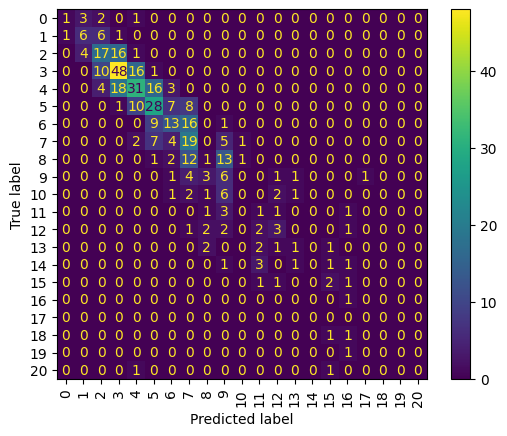

In [131]:
matrix = metrics.confusion_matrix(tester['true_price'], tester['predicted_price'])
display = metrics.ConfusionMatrixDisplay(confusion_matrix=matrix)
display.plot(xticks_rotation=90)
plt.show()